In [1]:
# =========================
"""
Versión fase 1: notebook / script monolítico compatible con Google Colab y Jupyter local.
- Mantiene el flujo actual
- Evita dependencias obligatorias de Colab
- Usa GPU local automáticamente si PyTorch la detecta
- Guarda resultados en un directorio configurable
"""


# =========================
# INSTALLS (solo referencia)

# =========================
# En notebook local, instalar primero:
# pip install -r requirements.txt


# =========================
# IMPORTS

# =========================
import os
import json
import random
import datetime
import shutil
import hashlib
import uuid
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# from IPython.display import Audio, display

# gTTS es opcional fuera de Colab
# try:
#     from gtts import gTTS
#     GTTS_AVAILABLE = True
# except Exception:
#     gTTS = None
#     GTTS_AVAILABLE = False
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
NVIDIA GeForce MX230


In [3]:
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
RUNS_DIR = PROJECT_ROOT / "runs"
CACHE_DIR = RUNS_DIR / "cache"
DATA_DIR = PROJECT_ROOT / "data"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# =========================
# PLATFORM / PATH SETUP

In [5]:
# =========================
def is_running_in_colab():
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


def setup_save_dir(
    local_save_dir="./runs",
    colab_drive_path="/content/drive/MyDrive/Tesis/2026-experimentacion oficial",
    mount_drive_if_needed=False,
):
    """
    Devuelve un Path donde se guardarán resultados.

    - En Colab:
        * Si mount_drive_if_needed=True, monta Drive y usa colab_drive_path
        * Si no, usa el filesystem local del runtime
    - En local:
        * Usa local_save_dir
    """
    if is_running_in_colab():
        if mount_drive_if_needed:
            try:
                from google.colab import drive  # type: ignore
                drive.mount("/content/drive")
                save_dir = Path(colab_drive_path)
            except Exception as e:
                print(f"⚠️ No se pudo montar Google Drive: {e}")
                save_dir = Path("./runs")
        else:
            save_dir = Path("./runs")
    else:
        save_dir = Path(local_save_dir)

    save_dir.mkdir(parents=True, exist_ok=True)
    return save_dir.resolve()


# Cambia esto si quieres otra ruta local
SAVE_DIR = setup_save_dir(
    local_save_dir="./runs",
    colab_drive_path="/content/drive/MyDrive/Tesis/2026-experimentacion oficial",
    mount_drive_if_needed=False,  # en Colab, poner True si quieres guardar en Drive
)

DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

print(f"📁 SAVE_DIR: {SAVE_DIR}")
print(f"📁 DATA_ROOT: {DATA_ROOT.resolve()}")

📁 SAVE_DIR: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs
📁 DATA_ROOT: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/data


In [6]:
# =========================
# REPRODUCIBILITY
# =========================
DEFAULT_SPLIT_SEED = 42
DEFAULT_EXPERIMENT_SEED = 42


def set_global_determinism(seed, deterministic_algorithms=False):
    """
    Configura la aleatoriedad global del experimento.

    Controla:
      - inicialización de pesos
      - orden de batches
      - RNG de numpy/random/torch
      - máscaras estocásticas de regularización
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    if deterministic_algorithms:
        torch.use_deterministic_algorithms(True)


set_global_determinism(DEFAULT_EXPERIMENT_SEED)


def seed_worker_factory(base_seed):
    """Crea un worker_init_fn determinista parametrizado por seed."""
    def seed_worker(worker_id):
        worker_seed = base_seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    return seed_worker


In [7]:
# =========================
# DEVICE CHECK

# =========================
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"✅ Device: {device}")
    if device.type == "cuda":
        print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
    else:
        print("ℹ️ No se detectó GPU CUDA. Se usará CPU.")
    return device


device = get_device()

✅ Device: cuda
GPU disponible: NVIDIA GeForce MX230


In [8]:
# =========================
# TRAINING UTILS

# =========================
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (pred.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def eval_one_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(X)
            loss = loss_fn(pred, y)

            total_loss += loss.item() * y.size(0)
            correct += (pred.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


def build_model(model_name, hidden_size=256, p=0.5, lambd=0.5, mask_normalization=False):
    """
    Factory para crear cualquiera de los 3 modelos.
    """
    model_name = model_name.lower()

    if model_name == "overfitnet":
        return OverfitNet(hidden_size=hidden_size)

    if model_name == "dropoutnet":
        return DropoutNet(hidden_size=hidden_size, p=p)

    if model_name == "dropconnectnet":
        return DropConnectNet(hidden_size=hidden_size, p=p)
    

    if model_name == "boostdropoutnet":
        return BoostDropoutNet(
            hidden_size=hidden_size,
            p=p,
            lambd=lambd,
            mask_normalization=mask_normalization
        )

    raise ValueError(
        "model_name debe ser uno de: "
        "'OverfitNet', 'DropoutNet', 'BoostDropoutNet', 'DropConnectNet'"
    )


def get_optimizer(model, lr=1e-3, weight_decay=0.0):
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


def init_history():
    return {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }


def plot_history(history, model_name="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curves - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curves - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


def to_jsonable(obj):
    """
    Convierte recursivamente objetos comunes no serializables por json
    a tipos compatibles.
    """
    if isinstance(obj, Path):
        return str(obj)

    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}

    if isinstance(obj, (list, tuple)):
        return [to_jsonable(x) for x in obj]

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        return float(obj)

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()

    return obj


def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    data = to_jsonable(data)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


def save_model_artifact(
    model,
    history,
    training_dir,
    artifact_type,
    epoch,
    val_loss,
    training_id,
    run_metadata,
    extra_info=None
):
    """
    artifact_type:
      - 'best_model'
      - 'last_model'
      - 'early_stopping'
    """
    training_dir = Path(training_dir)
    model_path = training_dir / f"{artifact_type}.pth"
    meta_path = training_dir / f"{artifact_type}.json"

    artifact_metadata = {
        "training_id": training_id,
        "artifact_type": artifact_type,
        "epoch": epoch,
        "val_loss": float(val_loss),
        "run_metadata": run_metadata,
        "history": history
    }

    if extra_info is not None:
        artifact_metadata["extra_info"] = extra_info

    torch.save(model.state_dict(), model_path)
    save_json(artifact_metadata, meta_path)

    print(f"💾 Guardado {artifact_type} en: {model_path}")


def save_history_csv(history, training_dir):
    training_dir = Path(training_dir)
    df = pd.DataFrame(history)
    csv_path = training_dir / "history.csv"
    df.to_csv(csv_path, index=False)
    print(f"📝 History CSV guardado en: {csv_path}")


def save_training_plot(history, training_dir, metric="loss"):
    training_dir = Path(training_dir)
    plt.figure(figsize=(8, 5))

    if metric == "loss":
        plt.plot(history["train_loss"], label="Train Loss")
        plt.plot(history["val_loss"], label="Validation Loss", linestyle="--")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss Curves")
        file_name = "plot_loss.png"

    elif metric == "accuracy":
        plt.plot(history["train_acc"], label="Train Accuracy")
        plt.plot(history["val_acc"], label="Validation Accuracy", linestyle="--")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy Curves")
        file_name = "plot_accuracy.png"

    else:
        raise ValueError("metric debe ser 'loss' o 'accuracy'")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = training_dir / file_name
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

    print(f"🖼️ Gráfico guardado en: {save_path}")


def generate_training_id(model_name):
    started_at = datetime.datetime.now()
    started_at_str = started_at.strftime("%Y-%m-%d-%H-%M-%S-%f")
    raw = f"{model_name}-{started_at_str}-{uuid.uuid4().hex}"
    short_hash = hashlib.md5(raw.encode()).hexdigest()[:8]
    training_id = f"{started_at_str}-{short_hash}"
    return training_id, started_at_str


def make_training_dir(save_dir, training_id):
    training_dir = Path(save_dir) / training_id
    training_dir.mkdir(parents=True, exist_ok=True)
    return training_dir


def build_run_metadata(
    training_id,
    training_dir,
    started_at,
    requested_model_name,
    instantiated_model_name,
    instantiated_model_class,
    lr,
    hidden_size,
    batch_size,
    num_epochs,
    early_stopping_patience,
    train_fraction,
    val_fraction,
    p,
    lambd,
    mask_normalization,
    weight_decay,
    normalize,
    num_workers,
    mean,
    std
):
    return {
        "training_id": training_id,
        "training_dir": str(training_dir),
        "started_at": started_at,
        "requested_model_name": requested_model_name,
        "instantiated_model_name": instantiated_model_name,
        "instantiated_model_class": instantiated_model_class,
        "model_name": instantiated_model_name,
        "hyperparameters": {
            "lr": lr,
            "hidden_size": hidden_size,
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "early_stopping_patience": early_stopping_patience,
            "train_fraction": train_fraction,
            "val_fraction": val_fraction,
            "p": p,
            "lambd": lambd,
            "mask_normalization": mask_normalization,
            "weight_decay": weight_decay,
            "normalize": normalize,
            "num_workers": num_workers,
        },
        "dataset_stats": {
            "mean": mean,
            "std": std
        }
    }


def save_run_metadata(training_dir, metadata):
    training_dir = Path(training_dir)
    path = training_dir / "run_metadata.json"
    save_json(metadata, path)
    print(f"🧾 Metadata general guardada en: {path}")


def generate_gridsearch_id():
    started_at = datetime.datetime.now()
    started_at_str = started_at.strftime("%Y-%m-%d-%H-%M-%S-%f")
    raw = f"{started_at_str}-gridsearch"
    short_hash = hashlib.md5(raw.encode()).hexdigest()[:8]
    gridsearch_id = f"{started_at_str}-{short_hash}"
    return gridsearch_id, started_at_str


def get_gridsearch_root_dir(save_dir):
    root = Path(save_dir) / "gridsearch"
    root.mkdir(parents=True, exist_ok=True)
    return root


def make_gridsearch_dir(save_dir, gridsearch_id):
    gridsearch_root = get_gridsearch_root_dir(save_dir)
    gridsearch_dir = gridsearch_root / gridsearch_id
    gridsearch_dir.mkdir(parents=True, exist_ok=True)
    return gridsearch_dir


def make_model_gridsearch_dir(gridsearch_dir, model_name):
    model_dir = Path(gridsearch_dir) / model_name
    model_dir.mkdir(parents=True, exist_ok=True)
    return model_dir


def expand_grid_config(param_grid):
    from itertools import product

    if not param_grid:
        return [{}]

    keys = list(param_grid.keys())
    values_product = product(*(param_grid[k] for k in keys))

    combinations = []
    for values in values_product:
        combinations.append(dict(zip(keys, values)))

    return combinations


def save_gridsearch_metadata(gridsearch_dir, metadata):
    gridsearch_dir = Path(gridsearch_dir)
    path = gridsearch_dir / "gridsearch_metadata.json"
    save_json(metadata, path)
    print(f"🧾 Metadata general del grid search guardada en: {path}")


def save_model_gridsearch_metadata(model_gridsearch_dir, metadata):
    model_gridsearch_dir = Path(model_gridsearch_dir)
    path = model_gridsearch_dir / "model_gridsearch_metadata.json"
    save_json(metadata, path)
    print(f"🧾 Metadata del grid search de modelo guardada en: {path}")

def materialize_early_stopping_artifact(
    training_dir,
    best_epoch,
    best_val_loss,
    early_stopping_patience,
    epochs_without_improvement,
    trigger_epoch,
    saved_from="best_model",
    reason="patience_triggered",
):
    training_dir = Path(training_dir)

    best_model_path = training_dir / "best_model.pth"
    best_model_meta_path = training_dir / "best_model.json"

    early_model_path = training_dir / "early_stopping.pth"
    early_model_meta_path = training_dir / "early_stopping.json"

    if not best_model_path.exists() or not best_model_meta_path.exists():
        raise FileNotFoundError(
            f"No existe best_model para materializar early_stopping en {training_dir}"
        )

    shutil.copyfile(best_model_path, early_model_path)
    shutil.copyfile(best_model_meta_path, early_model_meta_path)

    with open(early_model_meta_path, "r", encoding="utf-8") as f:
        early_meta = json.load(f)

    early_meta["artifact_type"] = "early_stopping"
    early_meta["extra_info"] = {
        "patience": early_stopping_patience,
        "best_epoch_before_stop": best_epoch,
        "best_val_loss_before_stop": best_val_loss,
        "epochs_without_improvement": epochs_without_improvement,
        "trigger_epoch": trigger_epoch,
        "saved_from": saved_from,
        "reason": reason,
    }

    save_json(early_meta, early_model_meta_path)

    print(f"💾 early_stopping guardado en: {early_model_path}")
    return early_model_path, early_model_meta_path

In [9]:
# =========================
# MODELS
# =========================
class OverfitNet(nn.Module):
    def __init__(self, hidden_size=256):
        super().__init__()
        self.name = "OverfitNet"
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)


class DropoutNet(nn.Module):
    def __init__(self, hidden_size=256, p=0.5):
        super().__init__()
        self.name = "DropoutNet"
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, 10)
        self.dropout = nn.Dropout(p=p)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        return self.fc4(x)


class BoostDropout(nn.Module):
    """
    Aplica una máscara de boost con probabilidad p.
    Las activaciones seleccionadas se multiplican por (1 + lambd).
    """
    def __init__(self, p=0.5, lambd=0.2, mask_normalization=False):
        super().__init__()
        assert 0 <= p <= 1, "p debe estar entre 0 y 1"
        self.p = p
        self.lambd = lambd
        self.mask_normalization = mask_normalization

    def forward(self, x):
        if not self.training or self.p == 0:
            return x

        mask = torch.ones_like(x)
        boost_positions = torch.rand_like(x) < self.p
        mask[boost_positions] = 1 + self.lambd

        if self.mask_normalization:
            alpha = 1 + self.p * self.lambd
            return x * (mask / alpha)
        else:
            return x * mask


class BoostDropoutNet(nn.Module):
    def __init__(self, hidden_size=256, p=0.5, lambd=0.5, mask_normalization=False):
        super().__init__()
        self.name = "BoostDropoutNet"
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, 10)

        self.boost_dropout = BoostDropout(
            p=p,
            lambd=lambd,
            mask_normalization=mask_normalization
        )

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.boost_dropout(x)
        x = F.relu(self.fc2(x))
        x = self.boost_dropout(x)
        x = F.relu(self.fc3(x))
        return self.fc4(x)


class DropConnect(nn.Linear):
    def __init__(self, in_features, out_features, bias=True, p=0.5):
        if not (0.0 <= p < 1.0):
            raise ValueError(f"p must be in [0, 1), got {p}")

        super().__init__(in_features, out_features, bias=bias)
        self.p = p

    def forward(self, input):
        if self.training and self.p > 0.0:
            keep_prob = 1.0 - self.p
            mask = (torch.rand_like(self.weight) < keep_prob).to(self.weight.dtype)
            weight = self.weight * mask / keep_prob
        else:
            weight = self.weight

        return F.linear(input, weight, self.bias)

    def extra_repr(self):
        base = super().extra_repr()
        return f"{base}, p={self.p}"


class DropConnectNet(nn.Module):
    def __init__(self, hidden_size=256, p=0.5):
        super().__init__()
        self.name = "DropConnectNet"
        self.flatten = nn.Flatten()
        self.fc1 = DropConnect(28 * 28, hidden_size, p=p)
        self.fc2 = DropConnect(hidden_size, hidden_size, p=p)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)


In [10]:
# =========================
# DATA

In [11]:
# =========================
def get_mnist_transform(normalize=True, mean=0.1307, std=0.3081):
    transform_list = [transforms.ToTensor()]

    if normalize:
        transform_list.append(transforms.Normalize((mean,), (std,)))

    return transforms.Compose(transform_list)


def count_classes_from_indices(targets, indices, num_classes=10):
    labels = targets[indices]
    return np.bincount(labels, minlength=num_classes)


def plot_class_distribution(train_counts, val_counts, title_suffix=""):
    plt.figure(figsize=(8, 4))
    x = np.arange(len(train_counts))
    plt.bar(x - 0.15, train_counts, width=0.3, label="Train")
    plt.bar(x + 0.15, val_counts, width=0.3, label="Val")
    plt.xticks(x)
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de muestras")
    plt.title(f"Distribución de clases {title_suffix}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def load_small_data(
    train_fraction=0.10,
    val_fraction=0.25,
    normalize=True,
    mean=0.1307,
    std=0.3081,
    cache_prefix="mnist_stratified",
    cache_dir=None,
    split_seed=DEFAULT_SPLIT_SEED,
    plot_distribution=True,
):
    """
    Devuelve un subconjunto estratificado y determinista de MNIST.

    split_seed controla exclusivamente el subset y el split train/val.
    """
    assert 0 < train_fraction <= 1, "train_fraction debe estar en (0, 1]"
    assert 0 < val_fraction < 1, "val_fraction debe estar en (0, 1)"

    transform = get_mnist_transform(normalize=normalize, mean=mean, std=std)
    full_train = datasets.MNIST(root=str(DATA_DIR), train=True, download=True, transform=transform)

    if cache_dir is None:
        cache_dir = CACHE_DIR

    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    cache_name = (
        f"{cache_prefix}_frac-{train_fraction}_val-{val_fraction}"
        f"_norm-{normalize}_mean-{mean}_std-{std}_splitseed-{split_seed}.npz"
    )
    cache_path = cache_dir / cache_name

    targets_np = full_train.targets.cpu().numpy()

    if cache_path.exists():
        data = np.load(cache_path, allow_pickle=False)
        train_idx = data["train_idx"]
        val_idx = data["val_idx"]
        print(f"📦 Split cargado desde cache: {cache_path}")
    else:
        rs = np.random.RandomState(split_seed)
        all_indices = np.arange(len(full_train))

        train_idx_list = []
        val_idx_list = []

        for cls in range(10):
            cls_indices = all_indices[targets_np == cls].copy()
            rs.shuffle(cls_indices)

            n_selected_cls = int(round(len(cls_indices) * train_fraction))
            cls_selected = cls_indices[:n_selected_cls]

            n_val_cls = int(round(len(cls_selected) * val_fraction))
            n_train_cls = len(cls_selected) - n_val_cls

            cls_train_idx = cls_selected[:n_train_cls]
            cls_val_idx = cls_selected[n_train_cls:]

            train_idx_list.extend(cls_train_idx.tolist())
            val_idx_list.extend(cls_val_idx.tolist())

        train_idx = np.array(train_idx_list, dtype=np.int64)
        val_idx = np.array(val_idx_list, dtype=np.int64)

        rs.shuffle(train_idx)
        rs.shuffle(val_idx)

        np.savez_compressed(cache_path, train_idx=train_idx, val_idx=val_idx)
        print(f"💾 Split guardado en cache: {cache_path}")

    train_ds = Subset(full_train, train_idx.tolist())
    val_ds = Subset(full_train, val_idx.tolist())

    train_counts = count_classes_from_indices(targets_np, train_idx, num_classes=10)
    val_counts = count_classes_from_indices(targets_np, val_idx, num_classes=10)

    print("\n📊 Distribución de clases (Train vs Val) - estratificada, fija y cacheada")
    for i in range(10):
        print(f"Clase {i}: Train={train_counts[i]}  Val={val_counts[i]}")

    if plot_distribution:
        title_suffix = (
            f"(frac={train_fraction}, val={val_fraction}, normalize={normalize}, split_seed={split_seed})"
        )
        plot_class_distribution(train_counts, val_counts, title_suffix=title_suffix)

    return train_ds, val_ds


def compute_dataset_mean_std(dataset, batch_size=512, num_workers=2):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False
    )

    channel_sum = 0.0
    channel_squared_sum = 0.0
    num_pixels = 0

    for images, _ in loader:
        channel_sum += images.sum(dim=[0, 2, 3])
        channel_squared_sum += (images ** 2).sum(dim=[0, 2, 3])
        num_pixels += images.size(0) * images.size(2) * images.size(3)

    mean = channel_sum / num_pixels
    std = torch.sqrt(channel_squared_sum / num_pixels - mean ** 2)

    return mean.item(), std.item()


def make_dataloaders(train_ds, val_ds, batch_size=64, num_workers=2, experiment_seed=DEFAULT_EXPERIMENT_SEED):
    generator = torch.Generator()
    generator.manual_seed(experiment_seed)
    worker_init_fn = seed_worker_factory(experiment_seed)

    pin_memory = device.type == "cuda"

    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        worker_init_fn=worker_init_fn,
        generator=generator
    )

    val_dl = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        worker_init_fn=worker_init_fn,
        generator=generator
    )

    return train_dl, val_dl


def make_test_dataloader(test_ds, batch_size=128, num_workers=2, experiment_seed=DEFAULT_EXPERIMENT_SEED):
    generator = torch.Generator()
    generator.manual_seed(experiment_seed)
    worker_init_fn = seed_worker_factory(experiment_seed)

    pin_memory = device.type == "cuda"

    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        worker_init_fn=worker_init_fn,
        generator=generator
    )

    return test_dl


def load_test_data(normalize=True, mean=0.1307, std=0.3081):
    transform = get_mnist_transform(normalize=normalize, mean=mean, std=std)
    test_ds = datasets.MNIST(
        root=str(DATA_ROOT),
        train=False,
        download=True,
        transform=transform
    )
    return test_ds


def train_model_on_mnist_subset(
    model_name="OverfitNet",
    lr=1e-3,
    hidden_size=256,
    batch_size=128,
    num_epochs=100,
    early_stopping_patience=10,
    train_fraction=0.10,
    val_fraction=0.25,
    p=0.5,
    lambd=0.5,
    mask_normalization=False,
    weight_decay=0.0,
    normalize=True,
    num_workers=2,
    plot_curves=True,
    save_final_csv=True,
    save_training_plots=True,
    base_save_dir=None,
    split_seed=DEFAULT_SPLIT_SEED,
    experiment_seed=DEFAULT_EXPERIMENT_SEED,
):
    print("\n" + "=" * 80)
    print(f"🚀 Entrenando modelo: {model_name}")
    print("=" * 80)
    print(f"lr={lr}")
    print(f"hidden_size={hidden_size}")
    print(f"batch_size={batch_size}")
    print(f"num_epochs={num_epochs}")
    print(f"early_stopping_patience={early_stopping_patience}")
    print(f"train_fraction={train_fraction}")
    print(f"val_fraction={val_fraction}")
    print(f"p={p}")
    print(f"lambd={lambd}")
    print(f"mask_normalization={mask_normalization}")
    print(f"weight_decay={weight_decay}")
    print(f"normalize={normalize}")
    print(f"num_workers={num_workers}")
    print(f"split_seed={split_seed}")
    print(f"experiment_seed={experiment_seed}")

    set_global_determinism(experiment_seed)

    training_id, started_at = generate_training_id(model_name)
    effective_save_dir = SAVE_DIR if base_save_dir is None else Path(base_save_dir)
    training_dir = make_training_dir(effective_save_dir, training_id)

    print(f"🆔 training_id: {training_id}")
    print(f"📁 training_dir: {training_dir}")

    train_ds_raw, val_ds_raw = load_small_data(
        train_fraction=train_fraction,
        val_fraction=val_fraction,
        normalize=False,
        split_seed=split_seed,
    )

    if normalize:
        mean, std = compute_dataset_mean_std(
            train_ds_raw,
            batch_size=batch_size,
            num_workers=num_workers
        )
        print(f"📊 mean del subset train: {mean}")
        print(f"📊 std del subset train: {std}")

        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((mean,), (std,))
        ])
    else:
        mean, std = None, None
        transform = transforms.ToTensor()

    full_train = datasets.MNIST(root=str(DATA_ROOT), train=True, download=True, transform=transform)

    train_ds = Subset(full_train, train_ds_raw.indices)
    val_ds = Subset(full_train, val_ds_raw.indices)

    train_dl, val_dl = make_dataloaders(
        train_ds=train_ds,
        val_ds=val_ds,
        batch_size=batch_size,
        num_workers=num_workers,
        experiment_seed=experiment_seed,
    )

    # Re-seed justo antes de construir el modelo para garantizar inicialización alineada.
    set_global_determinism(experiment_seed)
    model = build_model(
        model_name=model_name,
        hidden_size=hidden_size,
        p=p,
        lambd=lambd,
        mask_normalization=mask_normalization
    ).to(device)

    requested_model_name = model_name
    instantiated_model_name = model.name
    instantiated_model_class = model.__class__.__name__

    requested_model_name_normalized = requested_model_name.lower()
    instantiated_model_name_normalized = instantiated_model_name.lower()

    if requested_model_name_normalized != instantiated_model_name_normalized:
        raise RuntimeError(
            f"Inconsistencia de modelo: se pidió '{requested_model_name}' "
            f"pero se construyó '{instantiated_model_name}'."
        )

    optimizer = get_optimizer(model, lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    history = init_history()

    history["mean"] = mean
    history["std"] = std
    history["training_id"] = training_id
    history["split_seed"] = split_seed
    history["experiment_seed"] = experiment_seed

    run_metadata = build_run_metadata(
        training_id=training_id,
        training_dir=training_dir,
        started_at=started_at,
        requested_model_name=requested_model_name,
        instantiated_model_name=instantiated_model_name,
        instantiated_model_class=instantiated_model_class,
        lr=lr,
        hidden_size=hidden_size,
        batch_size=batch_size,
        num_epochs=num_epochs,
        early_stopping_patience=early_stopping_patience,
        train_fraction=train_fraction,
        val_fraction=val_fraction,
        p=p,
        lambd=lambd,
        mask_normalization=mask_normalization,
        weight_decay=weight_decay,
        normalize=normalize,
        num_workers=num_workers,
        mean=mean,
        std=std
    )
    run_metadata["seeds"] = {
        "split_seed": split_seed,
        "experiment_seed": experiment_seed,
    }

    save_run_metadata(training_dir, run_metadata)

    best_val_loss = float("inf")
    best_epoch = None
    epochs_without_improvement = 0
    early_stopping_saved = False

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_dl, loss_fn, optimizer, device)
        val_loss, val_acc = eval_one_epoch(model, val_dl, loss_fn, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"[{epoch}/{num_epochs}] "
            f"train_acc={tr_acc:.4f} "
            f"val_acc={val_acc:.4f} "
            f"train_loss={tr_loss:.4f} "
            f"val_loss={val_loss:.4f}"
        )

        save_model_artifact(
            model=model,
            history=history,
            training_dir=training_dir,
            artifact_type="last_model",
            epoch=epoch,
            val_loss=val_loss,
            training_id=training_id,
            run_metadata=run_metadata,
            extra_info={
                "best_val_loss_so_far": best_val_loss if best_val_loss != float("inf") else None
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0

            save_model_artifact(
                model=model,
                history=history,
                training_dir=training_dir,
                artifact_type="best_model",
                epoch=epoch,
                val_loss=val_loss,
                training_id=training_id,
                run_metadata=run_metadata,
                extra_info={
                    "best_epoch": best_epoch,
                    "best_val_loss": best_val_loss
                }
            )
        else:
            epochs_without_improvement += 1

        if (
            early_stopping_patience is not None
            and early_stopping_patience > 0
            and not early_stopping_saved
            and epochs_without_improvement >= early_stopping_patience
        ):
            materialize_early_stopping_artifact(
                training_dir=training_dir,
                best_epoch=best_epoch,
                best_val_loss=best_val_loss,
                early_stopping_patience=early_stopping_patience,
                epochs_without_improvement=epochs_without_improvement,
                trigger_epoch=epoch,
                saved_from="best_model",
                reason="patience_triggered",
            )
                    
            best_model_path = Path(training_dir) / "best_model.pth"
            best_model_meta_path = Path(training_dir) / "best_model.json"

            early_model_path = Path(training_dir) / "early_stopping.pth"
            early_model_meta_path = Path(training_dir) / "early_stopping.json"

            shutil.copyfile(best_model_path, early_model_path)
            shutil.copyfile(best_model_meta_path, early_model_meta_path)

            with open(early_model_meta_path, "r", encoding="utf-8") as f:
                early_meta = json.load(f)

            early_meta["artifact_type"] = "early_stopping"
            early_meta["extra_info"] = {
                "patience": early_stopping_patience,
                "best_epoch_before_stop": best_epoch,
                "best_val_loss_before_stop": best_val_loss,
                "epochs_without_improvement": epochs_without_improvement,
                "saved_from": "best_model"
            }

            save_json(early_meta, early_model_meta_path)

            early_stopping_saved = True
            print(f"⏹️ Early stopping cumplido en epoch {epoch}.")
            print(f"💾 early_stopping guardado en: {early_model_path}")

    if not early_stopping_saved:
        print("ℹ️ No se cumplió el criterio de early stopping durante este entrenamiento.")
        print("ℹ️ Se guardará igualmente el candidato a early stopping usando el mejor checkpoint final.")
    
        materialize_early_stopping_artifact(
            training_dir=training_dir,
            best_epoch=best_epoch,
            best_val_loss=best_val_loss,
            early_stopping_patience=early_stopping_patience,
            epochs_without_improvement=epochs_without_improvement,
            trigger_epoch=len(history["train_loss"]),
            saved_from="best_model",
            reason="max_epochs_reached",
        )
    
        early_stopping_saved = True

    if plot_curves:
        plot_history(history, model_name=model.name)

    if save_training_plots:
        save_training_plot(history, training_dir=training_dir, metric="loss")
        save_training_plot(history, training_dir=training_dir, metric="accuracy")

    if save_final_csv:
        save_history_csv(history, training_dir=training_dir)

    run_metadata["ended_at"] = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S-%f")
    run_metadata["results"] = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss if best_val_loss != float("inf") else None,
        "early_stopping_saved": early_stopping_saved,
        "early_stopping_reason": (
            "patience_triggered" if epochs_without_improvement >= (early_stopping_patience or float("inf"))
            else "max_epochs_reached"
        ),
        "finished_epoch": len(history["train_loss"])
    }
    run_metadata["generated_files"] = [
        "best_model.pth",
        "best_model.json",
        "last_model.pth",
        "last_model.json",
        "history.csv",
        "plot_loss.png",
        "plot_accuracy.png",
        "run_metadata.json"
    ]
    if early_stopping_saved:
        run_metadata["generated_files"].extend([
            "early_stopping.pth",
            "early_stopping.json"
        ])

    save_run_metadata(training_dir, run_metadata)

    test_results = evaluate_all_artifacts_on_test(training_dir)
    run_metadata["test_results"] = test_results

    for artifact_type in test_results.keys():
        test_eval_file = f"{artifact_type}_test_eval.json"
        if test_eval_file not in run_metadata["generated_files"]:
            run_metadata["generated_files"].append(test_eval_file)

    save_run_metadata(training_dir, run_metadata)

    print("✅ Entrenamiento finalizado.")
    return history, model


In [12]:
def load_model_artifact_for_eval(model_name, artifact_path, hyperparameters):
    """
    Reconstruye el modelo y carga los pesos de un artefacto .pth
    para evaluación.
    """
    model = build_model(
        model_name=model_name,
        hidden_size=hyperparameters.get("hidden_size", 256),
        p=hyperparameters.get("p", 0.5),
        lambd=hyperparameters.get("lambd", 0.5),
        mask_normalization=hyperparameters.get("mask_normalization", False)
    ).to(device)

    state_dict = torch.load(artifact_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def evaluate_saved_artifact_on_test(training_dir, artifact_type="best_model"):
    """
    Evalúa uno de los artefactos guardados de un entrenamiento
    sobre el test set de MNIST.

    artifact_type:
      - "best_model"
      - "early_stopping"
      - "last_model"
    """
    run_metadata_path = os.path.join(training_dir, "run_metadata.json")
    artifact_path = os.path.join(training_dir, f"{artifact_type}.pth")

    if not os.path.exists(run_metadata_path):
        raise FileNotFoundError(f"No existe run_metadata.json en {training_dir}")

    if not os.path.exists(artifact_path):
        return None

    with open(run_metadata_path, "r") as f:
        run_metadata = json.load(f)

    model_name = run_metadata["instantiated_model_name"]
    hp = run_metadata["hyperparameters"]

    normalize = hp.get("normalize", True)
    mean = run_metadata.get("dataset_stats", {}).get("mean")
    std = run_metadata.get("dataset_stats", {}).get("std")

    if normalize and (mean is None or std is None):
        raise ValueError(
            f"No hay mean/std guardados para evaluar en test el run {training_dir}"
        )

    test_ds = load_test_data(
        normalize=normalize,
        mean=mean if mean is not None else 0.1307,
        std=std if std is not None else 0.3081
    )
    experiment_seed = run_metadata.get("seeds", {}).get("experiment_seed", DEFAULT_EXPERIMENT_SEED)
    test_dl = make_test_dataloader(
        test_ds=test_ds,
        batch_size=hp.get("batch_size", 128),
        num_workers=hp.get("num_workers", 2),
        experiment_seed=experiment_seed
    )

    model = load_model_artifact_for_eval(
        model_name=model_name,
        artifact_path=artifact_path,
        hyperparameters=hp
    )

    loss_fn = nn.CrossEntropyLoss()
    test_loss, test_acc = eval_one_epoch(model, test_dl, loss_fn, device)

    result = {
        "artifact_type": artifact_type,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "num_test_samples": len(test_ds),
        "artifact_path": artifact_path
    }

    out_path = os.path.join(training_dir, f"{artifact_type}_test_eval.json")
    save_json(result, out_path)
    print(f"🧪 Evaluación de test guardada en: {out_path}")

    return result


def evaluate_all_artifacts_on_test(training_dir):
    """
    Evalúa best_model, early_stopping y last_model sobre test.
    """
    results = {}

    for artifact_type in ["best_model", "early_stopping", "last_model"]:
        res = evaluate_saved_artifact_on_test(training_dir, artifact_type=artifact_type)
        if res is not None:
            results[artifact_type] = res

    return results


In [13]:
# =========================
# GRID SEARCH UTILS
# =========================
GRIDSEARCH_ARTIFACT_TYPES = ["best_model", "early_stopping", "last_model"]
NON_GROUPING_RUN_PARAM_KEYS = {
    "model_name",
    "experiment_seed",
    "plot_curves",
    "save_final_csv",
    "save_training_plots",
    "base_save_dir",
}


def get_supported_model_params(model_name):
    common_params = {
        "model_name",
        "lr",
        "hidden_size",
        "batch_size",
        "num_epochs",
        "early_stopping_patience",
        "train_fraction",
        "val_fraction",
        "weight_decay",
        "normalize",
        "num_workers",
        "plot_curves",
        "save_final_csv",
        "save_training_plots",
        "split_seed",
        "experiment_seed",
    }

    model_name_lower = model_name.lower()

    if model_name_lower == "overfitnet":
        return common_params
    if model_name_lower == "dropoutnet":
        return common_params | {"p"}
    if model_name_lower == "dropconnectnet":
        return common_params | {"p"}
    if model_name_lower == "boostdropoutnet":
        return common_params | {"p", "lambd", "mask_normalization"}

    raise ValueError(
        "model_name debe ser uno de: "
        "'OverfitNet', 'DropoutNet', 'BoostDropoutNet', 'DropConnectNet'"
    )


def filter_params_for_model(model_name, params):
    supported = get_supported_model_params(model_name)
    return {k: v for k, v in params.items() if k in supported}


def make_experiment_seed_list(experiment_seeds=None, num_experiment_seeds=3, seed_start=101, seed_step=1):
    if experiment_seeds is not None:
        seeds = [int(seed) for seed in experiment_seeds]
        if len(seeds) == 0:
            raise ValueError("experiment_seeds no puede estar vacío")
        return seeds

    if num_experiment_seeds is None or int(num_experiment_seeds) <= 0:
        raise ValueError("num_experiment_seeds debe ser >= 1")

    return [int(seed_start + i * seed_step) for i in range(int(num_experiment_seeds))]


def _normalize_param_value(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, list):
        return tuple(_normalize_param_value(v) for v in value)
    if isinstance(value, dict):
        return tuple(sorted((k, _normalize_param_value(v)) for k, v in value.items()))
    return value


def canonicalize_group_params(params):
    return {
        k: v for k, v in params.items()
        if k not in NON_GROUPING_RUN_PARAM_KEYS
    }


def freeze_group_params(params):
    params = canonicalize_group_params(params)
    return tuple(sorted((k, _normalize_param_value(v)) for k, v in params.items()))


def _safe_mean(values):
    values = [v for v in values if v is not None]
    if not values:
        return None
    return float(np.mean(values))


def _safe_std(values):
    values = [v for v in values if v is not None]
    if not values:
        return None
    return float(np.std(values, ddof=0))


def _load_history_row_for_epoch(training_dir, epoch):
    training_dir = Path(training_dir)
    history_path = training_dir / "history.csv"
    if epoch is None or not history_path.exists():
        return None

    history_df = pd.read_csv(history_path)
    epoch_int = int(epoch)
    if epoch_int < 1 or epoch_int > len(history_df):
        return None

    return history_df.iloc[epoch_int - 1]


def extract_artifact_metrics_from_training_dir(training_dir, artifact_type):
    training_dir = Path(training_dir)
    artifact_json_path = training_dir / f"{artifact_type}.json"
    test_eval_path = training_dir / f"{artifact_type}_test_eval.json"

    if not artifact_json_path.exists():
        return None

    artifact_meta = _load_json(artifact_json_path)
    epoch = artifact_meta.get("epoch")
    val_loss = artifact_meta.get("val_loss")

    row = _load_history_row_for_epoch(training_dir, epoch)
    val_acc = None
    train_loss = None
    train_acc = None
    if row is not None:
        val_acc = float(row["val_acc"]) if "val_acc" in row else None
        train_loss = float(row["train_loss"]) if "train_loss" in row else None
        train_acc = float(row["train_acc"]) if "train_acc" in row else None
        if val_loss is None and "val_loss" in row:
            val_loss = float(row["val_loss"])

    test_loss = None
    test_acc = None
    if test_eval_path.exists():
        test_eval = _load_json(test_eval_path)
        test_loss = test_eval.get("test_loss")
        test_acc = test_eval.get("test_acc")

    return {
        "artifact_type": artifact_type,
        "exists": True,
        "epoch": int(epoch) if epoch is not None else None,
        "val_loss": float(val_loss) if val_loss is not None else None,
        "val_acc": val_acc,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": float(test_loss) if test_loss is not None else None,
        "test_acc": float(test_acc) if test_acc is not None else None,
        "artifact_json_path": str(artifact_json_path),
        "test_eval_path": str(test_eval_path) if test_eval_path.exists() else None,
    }


def build_seed_run_summary(training_id, training_dir, run_params, combo_id, combo_index, total_combinations, seed_index, total_seeds):
    training_dir = Path(training_dir)
    run_metadata_path = training_dir / "run_metadata.json"

    with open(run_metadata_path, "r", encoding="utf-8") as f:
        run_metadata = json.load(f)

    requested_model_name = run_metadata.get("requested_model_name")
    instantiated_model_name = run_metadata.get("instantiated_model_name") or run_metadata.get("model_name")
    instantiated_model_class = run_metadata.get("instantiated_model_class")

    artifacts = {}
    for artifact_type in GRIDSEARCH_ARTIFACT_TYPES:
        artifact_metrics = extract_artifact_metrics_from_training_dir(training_dir, artifact_type)
        if artifact_metrics is not None:
            artifacts[artifact_type] = artifact_metrics

    return {
        "training_id": training_id,
        "training_dir": str(training_dir),
        "combo_id": combo_id,
        "combo_index": combo_index,
        "total_combinations": total_combinations,
        "seed_index": seed_index,
        "total_seeds": total_seeds,
        "requested_model_name": requested_model_name,
        "instantiated_model_name": instantiated_model_name,
        "instantiated_model_class": instantiated_model_class,
        "params": dict(run_params),
        "group_params": canonicalize_group_params(run_params),
        "comparison_key": freeze_group_params(run_params),
        "seeds": run_metadata.get("seeds", {}),
        "results": run_metadata.get("results", {}),
        "artifacts": artifacts,
        "generated_files": run_metadata.get("generated_files", []),
        "test_results": run_metadata.get("test_results", {}),
    }


def aggregate_seed_runs_for_combo(seed_runs, artifact_types=GRIDSEARCH_ARTIFACT_TYPES):
    if not seed_runs:
        raise ValueError("seed_runs no puede estar vacío")

    first = seed_runs[0]
    aggregate = {
        "combo_id": first["combo_id"],
        "model_name": first.get("instantiated_model_name") or first.get("requested_model_name"),
        "group_params": dict(first["group_params"]),
        "comparison_key": first["comparison_key"],
        "seed_training_ids": [run["training_id"] for run in seed_runs],
        "seed_runs": seed_runs,
        "artifact_aggregates": {},
    }

    for artifact_type in artifact_types:
        per_seed = []
        for run in seed_runs:
            artifact_data = run.get("artifacts", {}).get(artifact_type)
            if artifact_data is not None:
                per_seed.append({
                    "training_id": run["training_id"],
                    "experiment_seed": run.get("seeds", {}).get("experiment_seed"),
                    **artifact_data,
                })

        val_losses = [item.get("val_loss") for item in per_seed]
        val_accs = [item.get("val_acc") for item in per_seed]
        train_losses = [item.get("train_loss") for item in per_seed]
        train_accs = [item.get("train_acc") for item in per_seed]
        test_losses = [item.get("test_loss") for item in per_seed]
        test_accs = [item.get("test_acc") for item in per_seed]

        representative_seed_run = None
        representative_training_id = None
        valid_for_rep = [item for item in per_seed if item.get("val_loss") is not None]
        if valid_for_rep:
            representative_seed_run = min(valid_for_rep, key=lambda x: x["val_loss"])
            representative_training_id = representative_seed_run["training_id"]

        aggregate["artifact_aggregates"][artifact_type] = {
            "artifact_type": artifact_type,
            "num_seed_runs": len(per_seed),
            "representative_training_id": representative_training_id,
            "mean_val_loss": _safe_mean(val_losses),
            "std_val_loss": _safe_std(val_losses),
            "mean_val_acc": _safe_mean(val_accs),
            "std_val_acc": _safe_std(val_accs),
            "mean_train_loss": _safe_mean(train_losses),
            "std_train_loss": _safe_std(train_losses),
            "mean_train_acc": _safe_mean(train_accs),
            "std_train_acc": _safe_std(train_accs),
            "mean_test_loss": _safe_mean(test_losses),
            "std_test_loss": _safe_std(test_losses),
            "mean_test_acc": _safe_mean(test_accs),
            "std_test_acc": _safe_std(test_accs),
            "seed_runs": per_seed,
        }

    return aggregate


def select_best_aggregate_for_artifact(aggregated_runs, artifact_type):
    candidates = []
    for combo in aggregated_runs:
        artifact_data = combo.get("artifact_aggregates", {}).get(artifact_type, {})
        mean_val_loss = artifact_data.get("mean_val_loss")
        if mean_val_loss is not None:
            candidates.append((mean_val_loss, combo))

    if not candidates:
        return None

    candidates.sort(key=lambda item: item[0])
    return candidates[0][1]


def build_best_hyperparameters_summary(gridsearch_metadata):
    summary = {
        "gridsearch_id": gridsearch_metadata["gridsearch_id"],
        "gridsearch_dir": gridsearch_metadata["gridsearch_dir"],
        "artifact_types": list(GRIDSEARCH_ARTIFACT_TYPES),
        "experiment_seeds": gridsearch_metadata.get("experiment_seeds", []),
        "models": {},
        "flat_index": [],
    }

    for model_name, model_info in gridsearch_metadata.get("models", {}).items():
        best_by_artifact = model_info.get("best_hyperparameters_by_artifact", {})
        summary["models"][model_name] = {
            "model_gridsearch_dir": model_info.get("model_gridsearch_dir"),
            "best_hyperparameters_by_artifact": best_by_artifact,
        }
        for artifact_type, artifact_summary in best_by_artifact.items():
            flat_entry = {
                "model_name": model_name,
                "artifact_type": artifact_type,
                **artifact_summary,
            }
            summary["flat_index"].append(flat_entry)

    return summary


def save_best_hyperparameters_summary(gridsearch_dir, summary):
    gridsearch_dir = Path(gridsearch_dir)
    out_path = gridsearch_dir / "best_hyperparameters_summary.json"
    save_json(summary, out_path)
    print(f"🧾 Resumen de mejores hiperparámetros guardado en: {out_path}")
    return out_path


def run_gridsearch(
    model_param_grids,
    common_params=None,
    save_dir=None,
    experiment_seeds=None,
    num_experiment_seeds=3,
    seed_start=101,
    seed_step=1,
):
    if save_dir is None:
        save_dir = SAVE_DIR

    if common_params is None:
        common_params = {}

    experiment_seed_list = make_experiment_seed_list(
        experiment_seeds=experiment_seeds,
        num_experiment_seeds=num_experiment_seeds,
        seed_start=seed_start,
        seed_step=seed_step,
    )

    gridsearch_id, gridsearch_started_at = generate_gridsearch_id()
    gridsearch_dir = make_gridsearch_dir(save_dir, gridsearch_id)

    print("\n" + "=" * 100)
    print("🔎 INICIANDO GRID SEARCH")
    print("=" * 100)
    print(f"🆔 gridsearch_id: {gridsearch_id}")
    print(f"📁 gridsearch_dir: {gridsearch_dir}")
    print(f"🌱 experiment_seeds: {experiment_seed_list}")

    gridsearch_metadata = {
        "gridsearch_id": gridsearch_id,
        "gridsearch_dir": str(gridsearch_dir),
        "started_at": gridsearch_started_at,
        "type": "gridsearch_multiseed",
        "common_params": common_params,
        "experiment_seeds": experiment_seed_list,
        "num_experiment_seeds": len(experiment_seed_list),
        "models": {},
        "generated_files": [
            "gridsearch_metadata.json"
        ]
    }
    save_gridsearch_metadata(gridsearch_dir, gridsearch_metadata)

    global_run_counter = 0

    for model_name, param_grid in model_param_grids.items():
        print("\n" + "-" * 100)
        print(f"📦 Grid search para modelo: {model_name}")
        print("-" * 100)

        model_gridsearch_dir = make_model_gridsearch_dir(gridsearch_dir, model_name)
        combinations = expand_grid_config(param_grid)

        model_grid_metadata = {
            "gridsearch_id": gridsearch_id,
            "model_name": model_name,
            "model_gridsearch_dir": str(model_gridsearch_dir),
            "started_at": datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S-%f"),
            "experiment_seeds": experiment_seed_list,
            "num_experiment_seeds": len(experiment_seed_list),
            "num_combinations": len(combinations),
            "param_grid": param_grid,
            "runs": [],
            "aggregated_runs": [],
            "best_hyperparameters_by_artifact": {},
            "generated_files": [
                "model_gridsearch_metadata.json"
            ]
        }
        save_model_gridsearch_metadata(model_gridsearch_dir, model_grid_metadata)

        for combo_idx, combo_params in enumerate(combinations, start=1):
            combo_seed_runs = []
            combo_id = f"combo_{combo_idx:04d}"

            for seed_idx, experiment_seed in enumerate(experiment_seed_list, start=1):
                global_run_counter += 1

                run_params = {}
                run_params.update(common_params)
                run_params.update(combo_params)
                run_params["experiment_seed"] = experiment_seed
                run_params = filter_params_for_model(model_name, run_params)
                run_params["model_name"] = model_name

                print("\n" + "~" * 100)
                print(f"▶️ Combo {combo_idx}/{len(combinations)} · Seed {seed_idx}/{len(experiment_seed_list)} para {model_name}")
                print(f"🌐 Run global {global_run_counter}")
                print(f"🌱 experiment_seed={experiment_seed}")
                print(f"⚙️ Params: {run_params}")
                print("~" * 100)

                history, model = train_model_on_mnist_subset(
                    **run_params,
                    base_save_dir=model_gridsearch_dir
                )

                training_id = history["training_id"]
                training_dir = Path(model_gridsearch_dir) / training_id
                seed_run_summary = build_seed_run_summary(
                    training_id=training_id,
                    training_dir=training_dir,
                    run_params=run_params,
                    combo_id=combo_id,
                    combo_index=combo_idx,
                    total_combinations=len(combinations),
                    seed_index=seed_idx,
                    total_seeds=len(experiment_seed_list),
                )

                model_grid_metadata["runs"].append(seed_run_summary)
                combo_seed_runs.append(seed_run_summary)
                save_model_gridsearch_metadata(model_gridsearch_dir, model_grid_metadata)

            aggregated_combo = aggregate_seed_runs_for_combo(combo_seed_runs)
            model_grid_metadata["aggregated_runs"].append(aggregated_combo)
            save_model_gridsearch_metadata(model_gridsearch_dir, model_grid_metadata)

        best_by_artifact = {}
        for artifact_type in GRIDSEARCH_ARTIFACT_TYPES:
            best_combo = select_best_aggregate_for_artifact(model_grid_metadata["aggregated_runs"], artifact_type)
            if best_combo is None:
                best_by_artifact[artifact_type] = None
                continue

            artifact_data = best_combo["artifact_aggregates"][artifact_type]
            best_by_artifact[artifact_type] = {
                "combo_id": best_combo["combo_id"],
                "params": best_combo["group_params"],
                "mean_val_loss": artifact_data.get("mean_val_loss"),
                "std_val_loss": artifact_data.get("std_val_loss"),
                "mean_val_acc": artifact_data.get("mean_val_acc"),
                "std_val_acc": artifact_data.get("std_val_acc"),
                "mean_test_loss": artifact_data.get("mean_test_loss"),
                "std_test_loss": artifact_data.get("std_test_loss"),
                "mean_test_acc": artifact_data.get("mean_test_acc"),
                "std_test_acc": artifact_data.get("std_test_acc"),
                "num_seed_runs": artifact_data.get("num_seed_runs"),
                "representative_training_id": artifact_data.get("representative_training_id"),
            }

        model_grid_metadata["ended_at"] = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S-%f")
        model_grid_metadata["best_hyperparameters_by_artifact"] = best_by_artifact
        model_grid_metadata["runs_summary_table"] = [
            {
                "combo_id": agg["combo_id"],
                "params": agg["group_params"],
                **{
                    f"{artifact_type}_mean_val_loss": agg["artifact_aggregates"].get(artifact_type, {}).get("mean_val_loss")
                    for artifact_type in GRIDSEARCH_ARTIFACT_TYPES
                }
            }
            for agg in sorted(
                model_grid_metadata["aggregated_runs"],
                key=lambda agg: min(
                    [
                        agg["artifact_aggregates"].get(artifact_type, {}).get("mean_val_loss")
                        for artifact_type in GRIDSEARCH_ARTIFACT_TYPES
                        if agg["artifact_aggregates"].get(artifact_type, {}).get("mean_val_loss") is not None
                    ] or [float("inf")]
                )
            )
        ]
        save_model_gridsearch_metadata(model_gridsearch_dir, model_grid_metadata)

        gridsearch_metadata["models"][model_name] = {
            "model_gridsearch_dir": str(model_gridsearch_dir),
            "num_combinations": len(combinations),
            "num_runs": len(model_grid_metadata["runs"]),
            "num_aggregated_runs": len(model_grid_metadata["aggregated_runs"]),
            "best_hyperparameters_by_artifact": best_by_artifact,
        }
        gridsearch_metadata["generated_files"].append(
            f"{model_name}/model_gridsearch_metadata.json"
        )
        save_gridsearch_metadata(gridsearch_dir, gridsearch_metadata)

    gridsearch_metadata["ended_at"] = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S-%f")
    best_hparams_summary = build_best_hyperparameters_summary(gridsearch_metadata)
    best_hparams_path = save_best_hyperparameters_summary(gridsearch_dir, best_hparams_summary)
    gridsearch_metadata.setdefault("generated_files", []).append(best_hparams_path.name)
    gridsearch_metadata["best_hyperparameters_summary"] = best_hparams_summary
    save_gridsearch_metadata(gridsearch_dir, gridsearch_metadata)

    comparison_plot_paths, comparison_summary = generate_gridsearch_comparison_plots(
        gridsearch_dir=gridsearch_dir,
        gridsearch_metadata=gridsearch_metadata
    )

    if comparison_plot_paths:
        gridsearch_metadata.setdefault("generated_files", [])
        gridsearch_metadata["generated_files"].extend(
            [str(Path(p).relative_to(gridsearch_dir)) for p in comparison_plot_paths]
        )
        gridsearch_metadata["comparison_plots"] = {
            "plot_files": [str(Path(p)) for p in comparison_plot_paths],
            "summary": comparison_summary
        }
        save_gridsearch_metadata(gridsearch_dir, gridsearch_metadata)

    test_plot_files = []
    for artifact_type in GRIDSEARCH_ARTIFACT_TYPES:
        plot_path = plot_gridsearch_test_comparison(
            gridsearch_metadata=gridsearch_metadata,
            artifact_type=artifact_type,
            save_dir=gridsearch_dir
        )
        if plot_path is not None:
            test_plot_files.append(os.path.basename(plot_path))

    gridsearch_metadata.setdefault("generated_files", [])
    gridsearch_metadata["generated_files"].extend(test_plot_files)
    save_gridsearch_metadata(gridsearch_dir, gridsearch_metadata)

    print("\n" + "=" * 100)
    print("✅ GRID SEARCH FINALIZADO")
    print("=" * 100)
    print(f"📁 Resultados en: {gridsearch_dir}")

    return gridsearch_metadata


In [14]:
# =========================
# WRAPPERS LISTOS PARA LOS MODELOS
# =========================
def train_overfitnet(
    lr=1e-3,
    hidden_size=256,
    batch_size=128,
    num_epochs=100,
    early_stopping_patience=10,
    train_fraction=0.10,
    val_fraction=0.25,
    weight_decay=0.0,
    normalize=True,
    num_workers=2,
    plot_curves=True,
    save_final_csv=True,
    save_training_plots=True,
    split_seed=DEFAULT_SPLIT_SEED,
    experiment_seed=DEFAULT_EXPERIMENT_SEED,
):
    return train_model_on_mnist_subset(
        model_name="OverfitNet",
        lr=lr,
        hidden_size=hidden_size,
        batch_size=batch_size,
        num_epochs=num_epochs,
        early_stopping_patience=early_stopping_patience,
        train_fraction=train_fraction,
        val_fraction=val_fraction,
        weight_decay=weight_decay,
        normalize=normalize,
        num_workers=num_workers,
        plot_curves=plot_curves,
        save_final_csv=save_final_csv,
        save_training_plots=save_training_plots,
        split_seed=split_seed,
        experiment_seed=experiment_seed,
    )


def train_DropoutNet(
    lr=1e-3,
    hidden_size=256,
    batch_size=128,
    num_epochs=100,
    early_stopping_patience=10,
    train_fraction=0.10,
    val_fraction=0.25,
    p=0.5,
    weight_decay=0.0,
    normalize=True,
    num_workers=2,
    plot_curves=True,
    save_final_csv=True,
    save_training_plots=True,
    split_seed=DEFAULT_SPLIT_SEED,
    experiment_seed=DEFAULT_EXPERIMENT_SEED,
):
    return train_model_on_mnist_subset(
        model_name="DropoutNet",
        lr=lr,
        hidden_size=hidden_size,
        batch_size=batch_size,
        num_epochs=num_epochs,
        early_stopping_patience=early_stopping_patience,
        train_fraction=train_fraction,
        val_fraction=val_fraction,
        p=p,
        weight_decay=weight_decay,
        normalize=normalize,
        num_workers=num_workers,
        plot_curves=plot_curves,
        save_final_csv=save_final_csv,
        save_training_plots=save_training_plots,
        split_seed=split_seed,
        experiment_seed=experiment_seed,
    )


def train_DropConnectNet(
    lr=1e-3,
    hidden_size=256,
    batch_size=128,
    num_epochs=100,
    early_stopping_patience=10,
    train_fraction=0.10,
    val_fraction=0.25,
    p=0.5,
    weight_decay=0.0,
    normalize=True,
    num_workers=2,
    plot_curves=True,
    save_final_csv=True,
    save_training_plots=True,
    split_seed=DEFAULT_SPLIT_SEED,
    experiment_seed=DEFAULT_EXPERIMENT_SEED,
):
    return train_model_on_mnist_subset(
        model_name="DropConnectNet",
        lr=lr,
        hidden_size=hidden_size,
        batch_size=batch_size,
        num_epochs=num_epochs,
        early_stopping_patience=early_stopping_patience,
        train_fraction=train_fraction,
        val_fraction=val_fraction,
        p=p,
        weight_decay=weight_decay,
        normalize=normalize,
        num_workers=num_workers,
        plot_curves=plot_curves,
        save_final_csv=save_final_csv,
        save_training_plots=save_training_plots,
        split_seed=split_seed,
        experiment_seed=experiment_seed,
    )


def train_BoostDropoutNet(
    lr=1e-3,
    hidden_size=256,
    batch_size=128,
    num_epochs=100,
    early_stopping_patience=10,
    train_fraction=0.10,
    val_fraction=0.25,
    p=0.5,
    lambd=0.5,
    mask_normalization=False,
    weight_decay=0.0,
    normalize=True,
    num_workers=2,
    plot_curves=True,
    save_final_csv=True,
    save_training_plots=True,
    split_seed=DEFAULT_SPLIT_SEED,
    experiment_seed=DEFAULT_EXPERIMENT_SEED,
):
    return train_model_on_mnist_subset(
        model_name="BoostDropoutNet",
        lr=lr,
        hidden_size=hidden_size,
        batch_size=batch_size,
        num_epochs=num_epochs,
        early_stopping_patience=early_stopping_patience,
        train_fraction=train_fraction,
        val_fraction=val_fraction,
        p=p,
        lambd=lambd,
        mask_normalization=mask_normalization,
        weight_decay=weight_decay,
        normalize=normalize,
        num_workers=num_workers,
        plot_curves=plot_curves,
        save_final_csv=save_final_csv,
        save_training_plots=save_training_plots,
        split_seed=split_seed,
        experiment_seed=experiment_seed,
    )


In [15]:
# # =========================
# # AUDIO ALERT

# # =========================
# def play_training_finished_audio(enable_audio=True, filename="voz_final.mp3"):
#     """
#     En local funciona si:
#     - tienes gTTS instalado
#     - tienes conexión a Internet (gTTS usa un servicio remoto)
#     Si falla, se degrada con un mensaje de texto.
#     """
#     if not enable_audio:
#         print("🔕 Audio deshabilitado.")
#         return

#     if not GTTS_AVAILABLE:
#         print("⚠️ gTTS no está disponible. Omitiendo audio.")
#         return

#     texto = (
#         "Entrenamiento finalizado correctamente maestro. "
#         "Vení a mirar los resultados antes de que se cierre el entorno de ejecución. "
#         "Los modelos han completado todas las épocas sin interrupciones críticas papá. "
#         "Las métricas de validación se encuentran disponibles en la carpeta de resultados. "
#         "Por favor máquina, revisá las curvas de pérdida y exactitud para verificar si el modelo está sobreajustando. "
#         "Recordá que el tiempo de sesión de Google Colab es limitado. Venii!! "
#         "Te recomiendo guardar los pesos entrenados y exportar los gráficos cuanto antes monstro. "
#         "Este mensaje se autodestruirá en tres, dos, uno... mentira, pero apurate igual. "
#         "Fin de la transmisión."
#     )

#     audio_path = Path(SAVE_DIR) / filename
#     try:
#         tts = gTTS(texto, lang="es")
#         tts.save(str(audio_path))
#         display(Audio(str(audio_path), autoplay=True))
#         print(f"🔊 Audio guardado en: {audio_path}")
#     except Exception as e:
#         print(f"⚠️ No se pudo generar/reproducir el audio: {e}")

## Ejemplos de ejecución
Descomentá solo lo que quieras correr.

In [16]:
# =========================
# GRID SEARCH COMPARISON PLOTS
# =========================
MODEL_DISPLAY_NAMES = {
    "OverfitNet": "OverfitNet",
    "DropoutNet": "Dropout",
    "DropConnectNet": "DropConnect",
    "BoostDropoutNet": "BoostDropout",
}

MODEL_MARKERS = {
    "OverfitNet": "o",
    "DropoutNet": "s",
    "DropConnectNet": "D",
    "BoostDropoutNet": "^",
}

ARTIFACT_TITLE_MAP = {
    "best_model": "Best model",
    "early_stopping": "Early stopping",
    "last_model": "Last model",
}


def _load_json(path):
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _load_model_grid_metadata(model_gridsearch_dir):
    model_gridsearch_dir = Path(model_gridsearch_dir)
    return _load_json(model_gridsearch_dir / "model_gridsearch_metadata.json")


def _frozen_params_without_p(params):
    ignored = {"p", "model_name"}
    return tuple(
        sorted(
            (k, _normalize_param_value(v))
            for k, v in params.items()
            if k not in ignored
        )
    )


def _aggregate_record_for_plot(agg_run, artifact_type):
    artifact_data = agg_run.get("artifact_aggregates", {}).get(artifact_type)
    if not artifact_data or artifact_data.get("mean_val_loss") is None:
        return None

    params = dict(agg_run.get("group_params", {}))
    model_name = agg_run.get("model_name")
    return {
        "model_name": model_name,
        "artifact_type": artifact_type,
        "combo_id": agg_run.get("combo_id"),
        "p": params.get("p"),
        "params": params,
        "comparison_key": _frozen_params_without_p(params),
        "val_loss": artifact_data.get("mean_val_loss"),
        "val_acc": artifact_data.get("mean_val_acc"),
        "test_loss": artifact_data.get("mean_test_loss"),
        "test_acc": artifact_data.get("mean_test_acc"),
        "std_val_loss": artifact_data.get("std_val_loss"),
        "std_val_acc": artifact_data.get("std_val_acc"),
        "num_seed_runs": artifact_data.get("num_seed_runs"),
    }


def _select_reference_group(records):
    valid_records = [r for r in records if r["val_loss"] is not None]
    if not valid_records:
        return None, []

    best_record = min(valid_records, key=lambda r: r["val_loss"])
    key = best_record["comparison_key"]
    matched = [r for r in valid_records if r["comparison_key"] == key]
    matched = sorted(matched, key=lambda r: (-1 if r["p"] is None else float(r["p"])))
    return best_record, matched


def _expand_baseline_points(series, x_reference):
    if not series or not x_reference:
        return series
    if all(item["p"] is None for item in series):
        template = dict(series[0])
        expanded = []
        for p in x_reference:
            new_item = dict(template)
            new_item["p"] = p
            expanded.append(new_item)
        return expanded
    return series


def _plot_metric_axis(ax, series_by_model, metric_key, title):
    has_data = False
    for model_name, series in series_by_model.items():
        valid_series = [item for item in series if item.get(metric_key) is not None]
        if not valid_series:
            continue
        has_data = True
        valid_series = sorted(valid_series, key=lambda item: item["p"] if item["p"] is not None else -1)
        xs = [item["p"] for item in valid_series]
        ys = [item[metric_key] for item in valid_series]
        ax.plot(xs, ys, linewidth=1.5, alpha=0.75, marker=MODEL_MARKERS.get(model_name, "o"), label=MODEL_DISPLAY_NAMES.get(model_name, model_name))
        ax.scatter(xs, ys, s=90 if model_name != "OverfitNet" else 120, marker=MODEL_MARKERS.get(model_name, "o"))

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("p", fontsize=12)
    ax.set_ylabel(metric_key.replace("_", " ").title(), fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4)
    if has_data:
        ax.legend(fontsize=11, loc="best", frameon=False)
    else:
        ax.text(0.5, 0.5, "Sin datos disponibles", ha="center", va="center", transform=ax.transAxes)


def generate_gridsearch_comparison_plots(gridsearch_dir, gridsearch_metadata):
    gridsearch_dir = Path(gridsearch_dir)

    model_runs = {}
    selection_summary = {}

    for model_name, model_info in gridsearch_metadata.get("models", {}).items():
        model_gridsearch_dir = Path(model_info["model_gridsearch_dir"])
        model_grid_metadata = _load_model_grid_metadata(model_gridsearch_dir)
        aggregated_runs = model_grid_metadata.get("aggregated_runs", [])

        model_runs[model_name] = {}
        selection_summary[model_name] = {}

        for artifact_type in GRIDSEARCH_ARTIFACT_TYPES:
            records = []
            for agg_run in aggregated_runs:
                record = _aggregate_record_for_plot(agg_run, artifact_type)
                if record is not None:
                    records.append(record)

            best_record, matched_records = _select_reference_group(records)
            model_runs[model_name][artifact_type] = matched_records
            selection_summary[model_name][artifact_type] = {
                "selected_best_combo_id": None if best_record is None else best_record["combo_id"],
                "selected_best_val_loss": None if best_record is None else best_record["val_loss"],
                "reference_params_without_p": None if best_record is None else {
                    k: v for k, v in best_record["params"].items() if k not in {"p", "model_name"}
                },
                "matched_combo_ids": [r["combo_id"] for r in matched_records],
                "matched_p_values": [r["p"] for r in matched_records],
            }

    plot_paths = []
    for artifact_type in GRIDSEARCH_ARTIFACT_TYPES:
        series_by_model = {
            model_name: model_runs.get(model_name, {}).get(artifact_type, [])
            for model_name in model_runs
        }

        union_p = sorted({
            float(item["p"])
            for series in series_by_model.values()
            for item in series
            if item.get("p") is not None
        })

        series_by_model = {
            model_name: _expand_baseline_points(series, union_p)
            for model_name, series in series_by_model.items()
        }

        if not any(series for series in series_by_model.values()):
            continue

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        _plot_metric_axis(
            axes[0],
            series_by_model,
            metric_key="val_loss",
            title=f"{ARTIFACT_TITLE_MAP[artifact_type]} · Mean validation loss vs p",
        )
        _plot_metric_axis(
            axes[1],
            series_by_model,
            metric_key="val_acc",
            title=f"{ARTIFACT_TITLE_MAP[artifact_type]} · Mean validation accuracy vs p",
        )

        fig.suptitle(f"Grid search comparison · {ARTIFACT_TITLE_MAP[artifact_type]}", fontsize=16)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        save_path = gridsearch_dir / f"comparison_{artifact_type}.png"
        fig.savefig(save_path, dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"🖼️ Gráfico comparativo guardado en: {save_path}")
        plot_paths.append(str(save_path))

    summary_path = gridsearch_dir / "comparison_plot_selection_summary.json"
    save_json(selection_summary, summary_path)
    return plot_paths, selection_summary


MODEL_LABELS = {
    "OverfitNet": "Overfit baseline",
    "DropoutNet": "Dropout",
    "BoostDropoutNet": "BoostDropout",
    "DropConnectNet": "DropConnect",
}


def get_model_marker(model_name):
    return MODEL_MARKERS.get(model_name, "X")


def get_model_label(model_name):
    return MODEL_LABELS.get(model_name, model_name)


def build_test_plot_points_for_artifact(gridsearch_metadata, artifact_type):
    all_points = []

    for model_name, model_info in gridsearch_metadata["models"].items():
        model_grid_dir = model_info["model_gridsearch_dir"]
        model_meta_path = os.path.join(model_grid_dir, "model_gridsearch_metadata.json")
        if not os.path.exists(model_meta_path):
            continue

        with open(model_meta_path, "r", encoding="utf-8") as f:
            model_meta = json.load(f)

        aggregated_runs = model_meta.get("aggregated_runs", [])
        if not aggregated_runs:
            continue

        candidate_runs = []
        for agg_run in aggregated_runs:
            artifact_data = agg_run.get("artifact_aggregates", {}).get(artifact_type, {})
            score = artifact_data.get("mean_val_loss")
            if score is not None:
                candidate_runs.append((score, agg_run))

        if not candidate_runs:
            continue

        candidate_runs.sort(key=lambda x: x[0])
        ref_run = candidate_runs[0][1]
        ref_params = dict(ref_run.get("group_params", {}))

        matched_runs = []
        for agg_run in aggregated_runs:
            params = dict(agg_run.get("group_params", {}))
            same_except_p = True
            all_keys = set(ref_params.keys()) | set(params.keys())
            for k in all_keys:
                if k in {"p", "model_name"}:
                    continue
                if ref_params.get(k) != params.get(k):
                    same_except_p = False
                    break
            if same_except_p:
                matched_runs.append(agg_run)

        if model_name.lower() == "overfitnet":
            matched_runs = [ref_run]

        for agg_run in matched_runs:
            params = agg_run.get("group_params", {})
            p = params.get("p", 0.0)
            artifact_data = agg_run.get("artifact_aggregates", {}).get(artifact_type, {})
            test_loss = artifact_data.get("mean_test_loss")
            test_acc = artifact_data.get("mean_test_acc")
            if test_loss is None or test_acc is None:
                continue
            all_points.append({
                "model_name": model_name,
                "label": get_model_label(model_name),
                "marker": get_model_marker(model_name),
                "p": p,
                "test_loss": test_loss,
                "test_acc": test_acc,
                "combo_id": agg_run.get("combo_id"),
                "reference_params": ref_params,
            })

    p_values = sorted({pt["p"] for pt in all_points if pt["model_name"].lower() != "overfitnet"})
    expanded_points = []
    for pt in all_points:
        if pt["model_name"].lower() == "overfitnet" and p_values:
            for p in p_values:
                clone = dict(pt)
                clone["p"] = p
                expanded_points.append(clone)
        else:
            expanded_points.append(pt)
    return expanded_points


def plot_gridsearch_test_comparison(gridsearch_metadata, artifact_type, save_dir):
    points = build_test_plot_points_for_artifact(gridsearch_metadata, artifact_type)
    if not points:
        print(f"⚠️ No hay puntos para plot de test de {artifact_type}")
        return None

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    metric_specs = [
        ("test_loss", "Mean Test Loss"),
        ("test_acc", "Mean Test Accuracy"),
    ]

    for ax, (metric_key, metric_label) in zip(axes, metric_specs):
        grouped = {}
        for pt in points:
            grouped.setdefault(pt["model_name"], []).append(pt)

        for model_name, model_points in grouped.items():
            model_points = sorted(model_points, key=lambda x: x["p"])
            x = [pt["p"] for pt in model_points]
            y = [pt[metric_key] for pt in model_points]
            ax.plot(x, y, marker=model_points[0]["marker"], label=model_points[0]["label"])
            ax.scatter(x, y, marker=model_points[0]["marker"], s=90)

        ax.set_title(f"{metric_label} vs p - {artifact_type}")
        ax.set_xlabel("p")
        ax.set_ylabel(metric_label)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()

    fig.tight_layout()
    out_path = os.path.join(save_dir, f"comparison_test_{artifact_type}.png")
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"🖼️ Gráfico de test guardado en: {out_path}")
    return out_path


## Tests de seeds, inicialización y agregación multiseed

Estos tests cubren los pasos 4, 5, 6 y 7:
- misma inicialización entre las 4 arquitecturas para capas equivalentes
- lista de seeds configurable
- agregación por combinación y selección separada para `best_model`, `early_stopping` y `last_model`


In [23]:
# =========================
# TESTS
# =========================
def get_named_linear_like_parameters(model):
    layer_names = ["fc1", "fc2", "fc3", "fc4"]
    snapshot = {}
    for layer_name in layer_names:
        layer = getattr(model, layer_name)
        snapshot[f"{layer_name}.weight"] = layer.weight.detach().cpu().clone()
        snapshot[f"{layer_name}.bias"] = layer.bias.detach().cpu().clone()
    return snapshot


def test_same_initialization_across_all_architectures(hidden_size=32, experiment_seed=314):
    model_names = ["OverfitNet", "DropoutNet", "DropConnectNet", "BoostDropoutNet"]
    snapshots = {}

    for model_name in model_names:
        set_global_determinism(experiment_seed)
        model = build_model(
            model_name=model_name,
            hidden_size=hidden_size,
            p=0.5,
            lambd=0.5,
            mask_normalization=False,
        )
        snapshots[model_name] = get_named_linear_like_parameters(model)

    baseline = snapshots[model_names[0]]
    for model_name in model_names[1:]:
        current = snapshots[model_name]
        for param_name, baseline_tensor in baseline.items():
            assert torch.allclose(baseline_tensor, current[param_name]), (
                f"Parámetro distinto entre {model_names[0]} y {model_name}: {param_name}"
            )

    print("✅ test_same_initialization_across_all_architectures")


def test_make_experiment_seed_list_is_configurable():
    assert make_experiment_seed_list(experiment_seeds=[7, 11, 13]) == [7, 11, 13]
    assert make_experiment_seed_list(num_experiment_seeds=4, seed_start=100, seed_step=5) == [100, 105, 110, 115]
    print("✅ test_make_experiment_seed_list_is_configurable")


def _fake_seed_run(combo_id, params, artifact_metrics_by_type, training_suffix, experiment_seed):
    return {
        "training_id": f"train_{training_suffix}",
        "combo_id": combo_id,
        "requested_model_name": "DropoutNet",
        "instantiated_model_name": "DropoutNet",
        "group_params": dict(params),
        "comparison_key": freeze_group_params(params),
        "seeds": {"experiment_seed": experiment_seed},
        "artifacts": artifact_metrics_by_type,
    }


def test_multiseed_aggregation_and_best_selection():
    combo_a_params = {"lr": 1e-3, "hidden_size": 256, "batch_size": 128, "p": 0.4, "split_seed": 42}
    combo_b_params = {"lr": 1e-3, "hidden_size": 256, "batch_size": 128, "p": 0.6, "split_seed": 42}

    combo_a_runs = [
        _fake_seed_run(
            "combo_0001",
            combo_a_params,
            {
                "best_model": {"artifact_type": "best_model", "exists": True, "val_loss": 0.30, "val_acc": 0.90, "train_loss": 0.20, "train_acc": 0.95, "test_loss": 0.40, "test_acc": 0.88},
                "early_stopping": {"artifact_type": "early_stopping", "exists": True, "val_loss": 0.28, "val_acc": 0.89, "train_loss": 0.25, "train_acc": 0.93, "test_loss": 0.39, "test_acc": 0.87},
                "last_model": {"artifact_type": "last_model", "exists": True, "val_loss": 0.45, "val_acc": 0.84, "train_loss": 0.18, "train_acc": 0.97, "test_loss": 0.48, "test_acc": 0.83},
            },
            training_suffix="a1",
            experiment_seed=101,
        ),
        _fake_seed_run(
            "combo_0001",
            combo_a_params,
            {
                "best_model": {"artifact_type": "best_model", "exists": True, "val_loss": 0.32, "val_acc": 0.89, "train_loss": 0.22, "train_acc": 0.94, "test_loss": 0.41, "test_acc": 0.87},
                "early_stopping": {"artifact_type": "early_stopping", "exists": True, "val_loss": 0.29, "val_acc": 0.88, "train_loss": 0.26, "train_acc": 0.92, "test_loss": 0.40, "test_acc": 0.86},
                "last_model": {"artifact_type": "last_model", "exists": True, "val_loss": 0.47, "val_acc": 0.83, "train_loss": 0.19, "train_acc": 0.96, "test_loss": 0.49, "test_acc": 0.82},
            },
            training_suffix="a2",
            experiment_seed=102,
        ),
    ]

    combo_b_runs = [
        _fake_seed_run(
            "combo_0002",
            combo_b_params,
            {
                "best_model": {"artifact_type": "best_model", "exists": True, "val_loss": 0.27, "val_acc": 0.91, "train_loss": 0.23, "train_acc": 0.94, "test_loss": 0.38, "test_acc": 0.89},
                "early_stopping": {"artifact_type": "early_stopping", "exists": True, "val_loss": 0.31, "val_acc": 0.87, "train_loss": 0.28, "train_acc": 0.91, "test_loss": 0.41, "test_acc": 0.85},
                "last_model": {"artifact_type": "last_model", "exists": True, "val_loss": 0.40, "val_acc": 0.85, "train_loss": 0.20, "train_acc": 0.96, "test_loss": 0.45, "test_acc": 0.84},
            },
            training_suffix="b1",
            experiment_seed=101,
        ),
        _fake_seed_run(
            "combo_0002",
            combo_b_params,
            {
                "best_model": {"artifact_type": "best_model", "exists": True, "val_loss": 0.29, "val_acc": 0.90, "train_loss": 0.24, "train_acc": 0.93, "test_loss": 0.39, "test_acc": 0.88},
                "early_stopping": {"artifact_type": "early_stopping", "exists": True, "val_loss": 0.33, "val_acc": 0.86, "train_loss": 0.29, "train_acc": 0.90, "test_loss": 0.42, "test_acc": 0.84},
                "last_model": {"artifact_type": "last_model", "exists": True, "val_loss": 0.39, "val_acc": 0.86, "train_loss": 0.21, "train_acc": 0.95, "test_loss": 0.44, "test_acc": 0.85},
            },
            training_suffix="b2",
            experiment_seed=102,
        ),
    ]

    agg_a = aggregate_seed_runs_for_combo(combo_a_runs)
    agg_b = aggregate_seed_runs_for_combo(combo_b_runs)
    aggregated_runs = [agg_a, agg_b]

    best_best_model = select_best_aggregate_for_artifact(aggregated_runs, "best_model")
    best_early = select_best_aggregate_for_artifact(aggregated_runs, "early_stopping")
    best_last = select_best_aggregate_for_artifact(aggregated_runs, "last_model")

    assert best_best_model["combo_id"] == "combo_0002"
    assert best_early["combo_id"] == "combo_0001"
    assert best_last["combo_id"] == "combo_0002"

    assert agg_a["artifact_aggregates"]["best_model"]["num_seed_runs"] == 2
    assert agg_b["artifact_aggregates"]["last_model"]["mean_val_loss"] == float(np.mean([0.40, 0.39]))
    print("✅ test_multiseed_aggregation_and_best_selection")


def run_multiseed_gridsearch_tests():
    test_same_initialization_across_all_architectures()
    test_make_experiment_seed_list_is_configurable()
    test_multiseed_aggregation_and_best_selection()
    print("🎉 Todos los tests multiseed pasaron")


# Descomentá para correrlos
run_multiseed_gridsearch_tests()


✅ test_same_initialization_across_all_architectures
✅ test_make_experiment_seed_list_is_configurable
✅ test_multiseed_aggregation_and_best_selection
🎉 Todos los tests multiseed pasaron



🚀 Entrenando modelo: DropConnectNet
lr=0.001
hidden_size=256
batch_size=128
num_epochs=10
early_stopping_patience=11
train_fraction=0.1
val_fraction=0.25
p=0.5
lambd=0.5
mask_normalization=False
weight_decay=0.0
normalize=False
num_workers=2
split_seed=42
experiment_seed=101
🆔 training_id: 2026-04-11-01-34-49-308176-46a0cc5e
📁 training_dir: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e
📦 Split cargado desde cache: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/cache/mnist_stratified_frac-0.1_val-0.25_norm-False_mean-0.1307_std-0.3081_splitseed-42.npz

📊 Distribución de clases (Train vs Val) - estratificada, fija y cacheada
Clase 0: Train=444  Val=148
Clase 1: Train=506  Val=168
Clase 2: Train=447  Val=149
Clase 3: Train=460  Val=153
Clase 4: Train=438  Val=146
Clase 5: Train=406  Val=136
Clase 6: Train=444  Val=148
Clase 7: Train=470  Val=156
Clase 8: Train=439  Val=146
Clase 9: Train=446  V

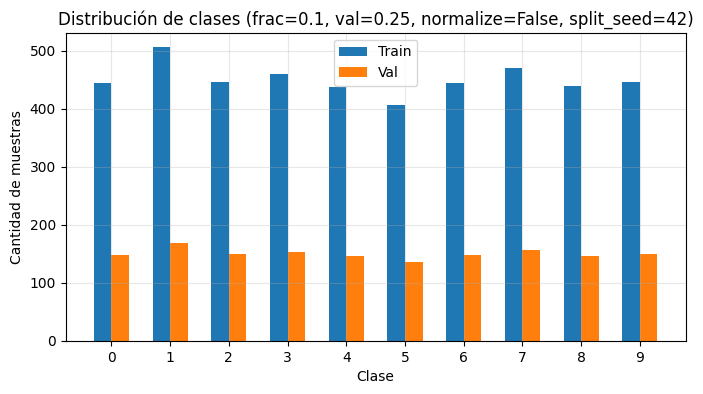

🧾 Metadata general guardada en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/run_metadata.json
[1/10] train_acc=0.4282 val_acc=0.6791 train_loss=1.8000 val_loss=0.9169
💾 Guardado last_model en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/last_model.pth
💾 Guardado best_model en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/best_model.pth
[2/10] train_acc=0.7836 val_acc=0.8212 train_loss=0.6732 val_loss=0.5623
💾 Guardado last_model en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/last_model.pth
💾 Guardado best_model en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/best_model.pth
[3/10] train_acc=0.8502 val_acc=0.8846 train_loss=0.4774 val_loss=0.4188
💾 Guard

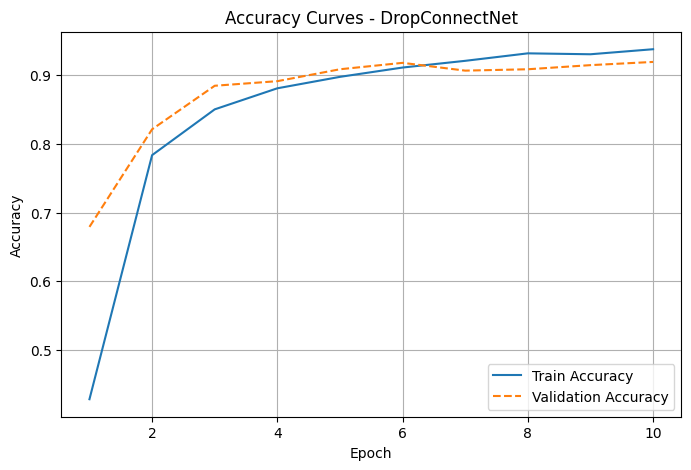

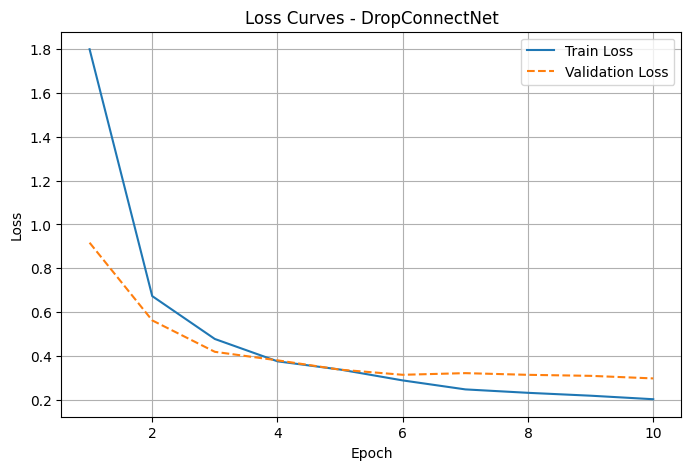

🖼️ Gráfico guardado en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/plot_loss.png
🖼️ Gráfico guardado en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/plot_accuracy.png
📝 History CSV guardado en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/history.csv
🧾 Metadata general guardada en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/run_metadata.json
🧪 Evaluación de test guardada en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/best_model_test_eval.json
🧪 Evaluación de test guardada en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-34-49-308176-46a0cc5e/early_stopping_test_eval.json
🧪 Evaluación de test guardada en: /

In [24]:
# =========================
# EXAMPLES / RUN
# =========================
# Ejecuta solo los bloques que quieras. No es necesario correr todo junto.

# -------- Ejemplo 1: OverfitNet --------
# history_overfit, model_overfit = train_overfitnet(
#     lr=1e-3,
#     hidden_size=256,
#     batch_size=128,
#     num_epochs=30,
#     early_stopping_patience=10,
#     train_fraction=0.10,
#     val_fraction=0.25,
#     weight_decay=0.0,
#     normalize=False,
#     num_workers=2,
#     plot_curves=True,
#     save_final_csv=True,
#     split_seed=42,
#     experiment_seed=101,
# )


# -------- Ejemplo 2: DropoutNet --------
# history_dropout, model_dropout = train_DropoutNet(
#     lr=1e-3,
#     hidden_size=256,
#     batch_size=128,
#     num_epochs=30,
#     early_stopping_patience=5,
#     train_fraction=0.1,
#     val_fraction=0.25,
#     p=0.5,
#     weight_decay=0.0,
#     normalize=False,
#     num_workers=2,
#     plot_curves=True,
#     save_final_csv=True,
#     split_seed=42,
#     experiment_seed=101
# )


# # -------- Ejemplo 3: train_DropConnectNet --------
history_boost, model_boost = train_DropConnectNet(
    lr=1e-3,
    hidden_size=256,
    batch_size=128,
    num_epochs=10,
    early_stopping_patience=11,
    train_fraction=0.1,
    val_fraction=0.25,
    p=0.5,
    weight_decay=0.0,
    normalize=False,
    num_workers=2,
    plot_curves=True,
    save_final_csv=True,
    split_seed=42,
    experiment_seed=101
)


# # -------- Ejemplo 4: BoostDropoutNet --------
# history_boost, model_boost = train_BoostDropoutNet(
#     lr=1e-3,
#     hidden_size=256,
#     batch_size=128,
#     num_epochs=10,
#     early_stopping_patience=11,
#     train_fraction=0.1,
#     val_fraction=0.25,
#     p=0.5,
#     lambd=0.6,
#     weight_decay=0.0,
#     normalize=False,
#     num_workers=2,
#     plot_curves=True,
#     save_final_csv=True,
#     split_seed=42,
#     experiment_seed=101
# )


# -------- Ejemplo 5: Grid Search multiseed --------
# gridsearch_results = run_gridsearch(
#     model_param_grids={
#         "OverfitNet": {
#             "lr": [1e-3],
#             "hidden_size": [256],
#             "batch_size": [128],
#         },
#         "DropoutNet": {
#             "lr": [1e-3],
#             "hidden_size": [256],
#             "batch_size": [128],
#             "p": [0.4, 0.8],
#         },
#         "DropConnectNet": {
#             "lr": [1e-3],
#             "hidden_size": [256],
#             "batch_size": [128],
#             "p": [0.4, 0.8],
#         },
#         "BoostDropoutNet": {
#             "lr": [1e-3],
#             "hidden_size": [256],
#             "batch_size": [128],
#             "p": [0.4, 0.8],
#             "lambd": [0.5],
#             "mask_normalization": [False],
#         },
#     },
#     common_params={
#         "num_epochs": 2,
#         "early_stopping_patience": 10,
#         "train_fraction": 0.10,
#         "val_fraction": 0.25,
#         "weight_decay": 0.0,
#         "normalize": True,
#         "num_workers": 2,
#         "plot_curves": True,
#         "save_final_csv": True,
#         "save_training_plots": True,
#         "split_seed": 42,
#     },
#     experiment_seeds=[101, 102],
# )


In [19]:
print("listo")

listo



🚀 Entrenando modelo: DropConnectNet
lr=0.001
hidden_size=256
batch_size=128
num_epochs=10
early_stopping_patience=11
train_fraction=0.1
val_fraction=0.25
p=0.5
lambd=0.5
mask_normalization=False
weight_decay=0.0
normalize=False
num_workers=2
split_seed=42
experiment_seed=101
🆔 training_id: 2026-04-11-01-35-12-827662-81cc77e4
📁 training_dir: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4
📦 Split cargado desde cache: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/cache/mnist_stratified_frac-0.1_val-0.25_norm-False_mean-0.1307_std-0.3081_splitseed-42.npz

📊 Distribución de clases (Train vs Val) - estratificada, fija y cacheada
Clase 0: Train=444  Val=148
Clase 1: Train=506  Val=168
Clase 2: Train=447  Val=149
Clase 3: Train=460  Val=153
Clase 4: Train=438  Val=146
Clase 5: Train=406  Val=136
Clase 6: Train=444  Val=148
Clase 7: Train=470  Val=156
Clase 8: Train=439  Val=146
Clase 9: Train=446  V

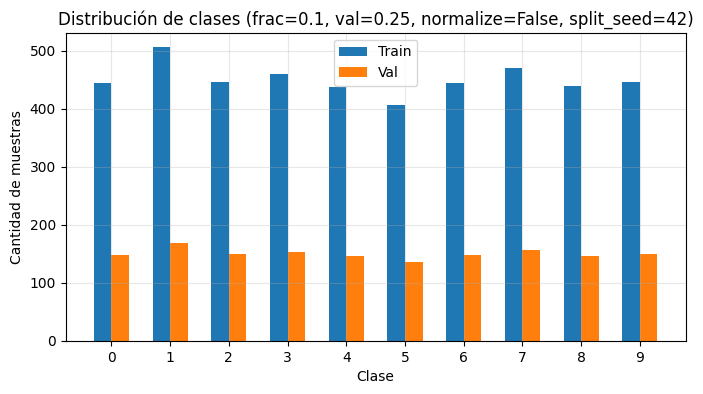

🧾 Metadata general guardada en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/run_metadata.json
[1/10] train_acc=0.4282 val_acc=0.6791 train_loss=1.8000 val_loss=0.9169
💾 Guardado last_model en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/last_model.pth
💾 Guardado best_model en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/best_model.pth
[2/10] train_acc=0.7836 val_acc=0.8212 train_loss=0.6732 val_loss=0.5623
💾 Guardado last_model en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/last_model.pth
💾 Guardado best_model en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/best_model.pth
[3/10] train_acc=0.8502 val_acc=0.8846 train_loss=0.4774 val_loss=0.4188
💾 Guard

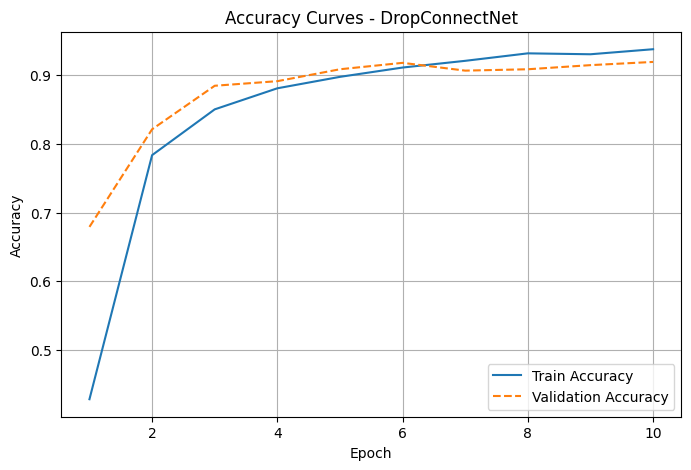

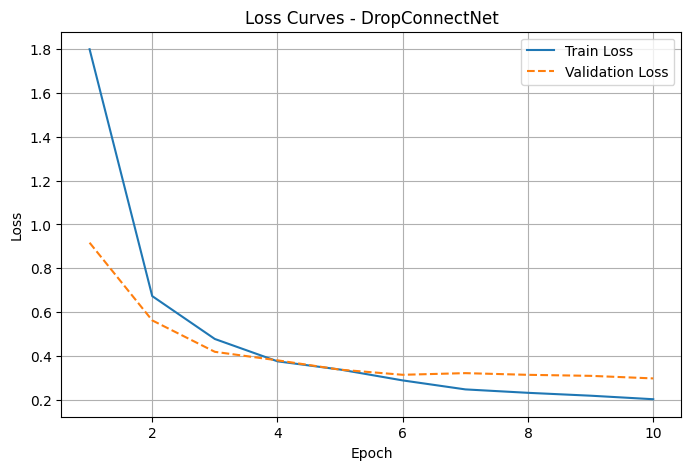

🖼️ Gráfico guardado en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/plot_loss.png
🖼️ Gráfico guardado en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/plot_accuracy.png
📝 History CSV guardado en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/history.csv
🧾 Metadata general guardada en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/run_metadata.json
🧪 Evaluación de test guardada en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/best_model_test_eval.json
🧪 Evaluación de test guardada en: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/2026-04-11-01-35-12-827662-81cc77e4/early_stopping_test_eval.json
🧪 Evaluación de test guardada en: /

In [25]:
history_boost, model_boost = train_DropConnectNet(
    lr=1e-3,
    hidden_size=256,
    batch_size=128,
    num_epochs=10,
    early_stopping_patience=11,
    train_fraction=0.1,
    val_fraction=0.25,
    p=0.5,
    weight_decay=0.0,
    normalize=False,
    num_workers=2,
    plot_curves=True,
    save_final_csv=True,
    split_seed=42,
    experiment_seed=101
)